In [2]:
from langgraph. graph import StateGraph, START, END
from typing import TypedDict
import pandas as pd
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

d:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [13]:
class BatsmanState(TypedDict):
    runs: int
    balls:int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str


In [ ]:
def calculate_SR(state: BatsmanState) -> BatsmanState:
    sr = (state['runs']/ state['balls'])* 100
    state['sr'] = sr
    return {'sr':sr}

def calculate_BPB(state:BatsmanState) -> BatsmanState:
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    state['bpb'] = bpb
    return {'bpb': bpb}

def calculate_boundary_percent(state:BatsmanState) -> BatsmanState:
    bp = (((state['fours']*4)+(state['sixes']*6)) / state['runs'])*100
    state['boundary_percentage'] = bp
    return {'boundary_percentage': bp}

def summary(state:BatsmanState) -> BatsmanState:
    summary = f"strike Rate: {state['sr']}\nBalls per boundary: {state['bpb']}\nboundary_percentage: {state['boundary_percentage']}"
    
    state['summary'] = summary
    return {'summary': summary}

In [39]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_SR', calculate_SR)
graph.add_node('calculate_BPB', calculate_BPB)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_SR')
graph.add_edge(START,'calculate_BPB')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_SR', 'summary')
graph.add_edge('calculate_BPB', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
 

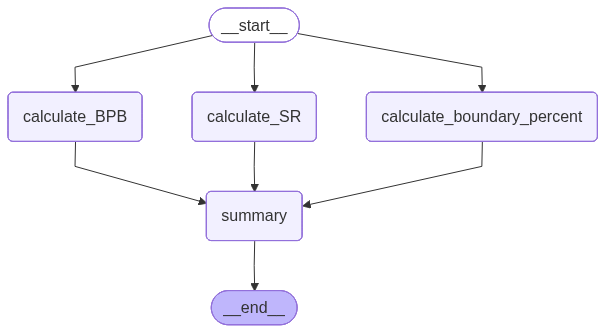

In [40]:
workflow

In [41]:
initial_state = {
    'runs': 100,
    'balls': 60,
    'fours':10,
    'sixes': 5

}
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.66666666666669,
 'bpb': 4.0,
 'boundary_percentage': 70.0,
 'summary': 'strike Rate: 166.66666666666669\nBalls per boundary: 4.0\nboundary_percentage: 70.0'}